In [1]:
import warnings
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
warnings.filterwarnings("ignore")

<h1>Load and Prepare Data</h1>

In [3]:
image = Image.open("kratos.png").convert("L")

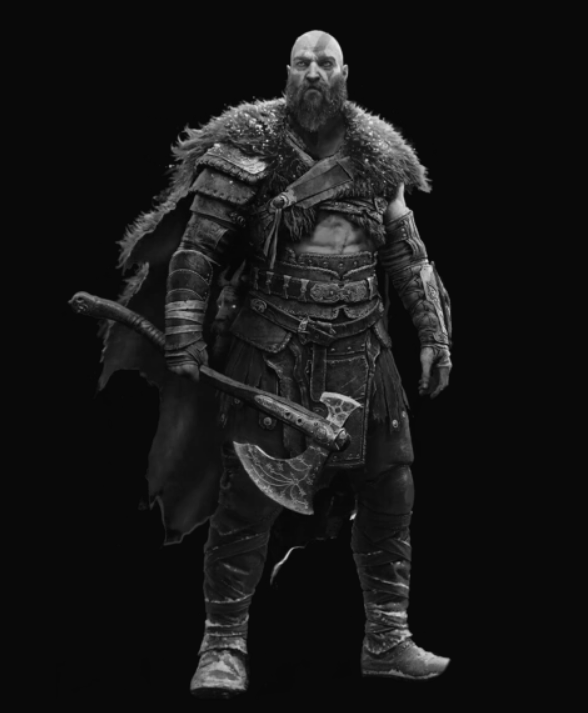

In [4]:
image

In [5]:
image_array = np.array(image)

In [6]:
mean = np.mean(image_array)
std = np.std(image_array)

#standaraization

stan_data = (image_array - mean) / std

In [7]:
np.mean(stan_data)

np.float64(-3.470989502143585e-17)

In [8]:
np.std(stan_data)

np.float64(0.9999999999999999)

In [9]:
cov_matrix = np.cov(stan_data)

In [10]:
image_array.shape

(713, 588)

In [11]:
cov_matrix.shape

(713, 713)

<h1>Eigen Decomposition and Identifying Principal Components</h1>

In [12]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

sorted_index = np.argsort(eigenvalues)[::-1]

sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

In [13]:
eigenvalues

array([ 1.94650197e+02+0.00000000e+00j,  1.10336343e+02+0.00000000e+00j,
        5.78500590e+01+0.00000000e+00j,  4.43731023e+01+0.00000000e+00j,
        3.24049766e+01+0.00000000e+00j,  2.35278769e+01+0.00000000e+00j,
        2.05282377e+01+0.00000000e+00j,  1.71279912e+01+0.00000000e+00j,
        1.41654922e+01+0.00000000e+00j,  1.24328081e+01+0.00000000e+00j,
        1.06793051e+01+0.00000000e+00j,  9.50539310e+00+0.00000000e+00j,
        7.45181007e+00+0.00000000e+00j,  7.02559744e+00+0.00000000e+00j,
        6.29179442e+00+0.00000000e+00j,  5.54382077e+00+0.00000000e+00j,
        5.35216593e+00+0.00000000e+00j,  4.82301766e+00+0.00000000e+00j,
        4.52416052e+00+0.00000000e+00j,  4.40900256e+00+0.00000000e+00j,
        3.54210335e+00+0.00000000e+00j,  3.49313677e+00+0.00000000e+00j,
        3.13348543e+00+0.00000000e+00j,  3.03061530e+00+0.00000000e+00j,
        2.65074180e+00+0.00000000e+00j,  2.58259278e+00+0.00000000e+00j,
        2.37403350e+00+0.00000000e+00j,  2.24334133

In [14]:
eigenvectors

array([[-1.68617816e-16+0.00000000e+00j,  2.20719521e-16+0.00000000e+00j,
        -2.68178641e-16+0.00000000e+00j, ...,
        -1.47790466e-07-5.94737435e-08j, -1.47790466e-07+5.94737435e-08j,
         1.19701754e-07+0.00000000e+00j],
       [ 4.60103597e-17+0.00000000e+00j, -1.16285333e-19+0.00000000e+00j,
         4.79079015e-17+0.00000000e+00j, ...,
        -1.15434099e-06-7.18799825e-07j, -1.15434099e-06+7.18799825e-07j,
         3.41464955e-07+0.00000000e+00j],
       [-6.93935390e-16+0.00000000e+00j, -4.96231286e-17+0.00000000e+00j,
         1.24851401e-17+0.00000000e+00j, ...,
         1.57775704e-07+8.06694155e-08j,  1.57775704e-07-8.06694155e-08j,
        -8.73712729e-08+0.00000000e+00j],
       ...,
       [-9.35301954e-19+0.00000000e+00j, -1.29060434e-18+0.00000000e+00j,
        -7.02157372e-19+0.00000000e+00j, ...,
         6.75330110e-05+3.69449296e-04j,  6.75330110e-05-3.69449296e-04j,
         7.46280628e-04+0.00000000e+00j],
       [-9.35301954e-19+0.00000000e+00j, -1.

In [15]:
k = 50

top_k_eigenvectors = sorted_eigenvectors[:, :k]
explained_variance = sorted_eigenvalues / np.sum(sorted_eigenvalues)

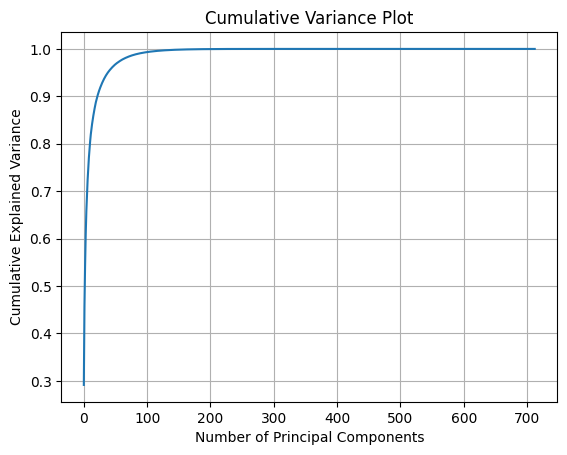

In [16]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Plot")
plt.grid()
plt.show()

<h1>Reconstruction and Experiment</h1>

In [17]:
stan_data.shape

(713, 588)

In [18]:
top_k_eigenvectors.shape

(713, 50)

In [19]:
Z = stan_data.T @ top_k_eigenvectors

In [20]:
reconstructed = (Z @ top_k_eigenvectors.T).T

# restore original scale
reconstructed = reconstructed * std + mean

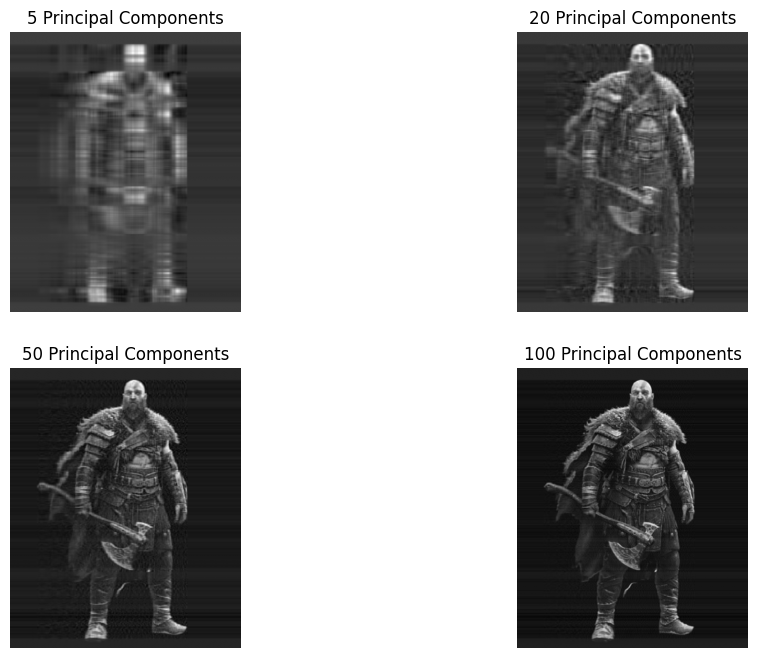

In [21]:
k_values = [5, 20, 50, 100]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):

    W_k = sorted_eigenvectors[:, :k]

    # projection
    Z = stan_data.T @ W_k

    # reconstruction
    reconstructed = Z @ W_k.T
    reconstructed = reconstructed.T

    reconstructed = reconstructed * std + mean

    # remove imaginary part
    reconstructed = np.real(reconstructed)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed, cmap="gray")
    plt.title(f"{k} Principal Components")
    plt.axis("off")

plt.show()

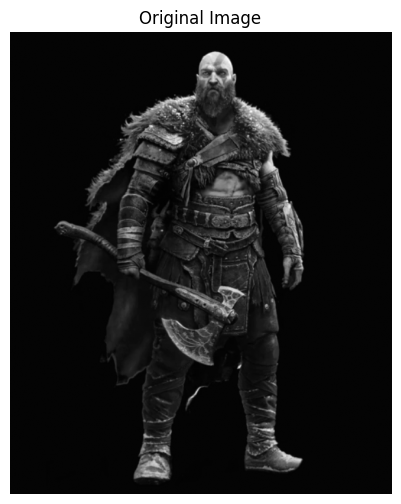

In [22]:
plt.figure(figsize=(6,6))
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()